<a href="https://colab.research.google.com/github/ketanp23/LLMclass/blob/main/Lab1_Word_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1 · Word Embeddings — Word2Vec & GloVe

**Course:** Language Models — From N-grams to Transformers
**Goal:** Represent words as dense vectors where *geometry encodes meaning*.

You will:
- Train a **Word2Vec** model on a real corpus with `gensim`
- Explore **similarity** and **analogies** (`king − man + woman ≈ queen`)
- **Visualize** embeddings in 2-D
- Load **pretrained GloVe** vectors and compare

> **Runtime tip:** this runs fine on a free Colab CPU. `Runtime → Run all` works end-to-end.


## 1 · Setup

`gensim` gives us Word2Vec plus a downloader for popular corpora and pretrained vectors.

In [1]:

!pip uninstall -y numpy scipy # This might remove other packages that rely on numpy/scipy
!pip install -q numpy==1.26.4 scipy==1.12.0 "gensim>=4.3"
import gensim
print("gensim", gensim.__version__)

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.12.0
Uninstalling scipy-1.12.0:
  Successfully uninstalled scipy-1.12.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires scipy>=1.13, but you have scipy 1.12.0 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires scipy>=1.13, but you have scipy 1.12.0 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires scipy>=1.13, but you have scipy 1.12.0 which is incompa

## 2 · Get a training corpus

We use `text8` — the first 100 MB of cleaned Wikipedia, a classic benchmark for word vectors. `gensim.downloader` fetches it for us (~30 MB download).

In [2]:
import gensim.downloader as api

# text8 is a list-of-tokens corpus, streamed sentence by sentence
dataset = api.load("text8")
sentences = list(dataset)
print(f"Sentences (chunks): {len(sentences)}")
print(f"First sentence starts: {sentences[0][:12]}")

[==================================================] 100.0% 31.6/31.6MB downloaded
Sentences (chunks): 1701
First sentence starts: ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working']


## 3 · Train Word2Vec

Word2Vec learns embeddings by predicting context words. Two flavours:
- **CBOW** — predict the center word from its context (`sg=0`)
- **Skip-gram** — predict the context from the center word (`sg=1`), usually better for rare words

Key hyperparameters: `vector_size` (dimensions), `window` (context width), `min_count` (ignore rare words).

In [3]:
from gensim.models import Word2Vec
import time

t0 = time.time()
model = Word2Vec(
    sentences,
    vector_size=100,   # embedding dimension
    window=5,          # context window
    min_count=5,       # drop words seen < 5 times
    sg=1,              # 1 = skip-gram, 0 = CBOW
    workers=4,
    epochs=5,
)
print(f"Trained in {time.time() - t0:.1f}s")
print(f"Vocabulary size: {len(model.wv):,}")
print(f"Each word is a vector of shape: {model.wv['king'].shape}")

Trained in 563.3s
Vocabulary size: 71,290
Each word is a vector of shape: (100,)


## 4 · Nearest neighbours

If the geometry is meaningful, the closest vectors to a word should be *semantically* related words.

In [4]:
for word in ["king", "computer", "france", "happy"]:
    neighbours = model.wv.most_similar(word, topn=5)
    print(f"\n{word!r} is closest to:")
    for w, score in neighbours:
        print(f"   {w:15s} {score:.3f}")


'king' is closest to:
   valdemar        0.766
   canute          0.760
   prince          0.751
   haakon          0.741
   pretender       0.731

'computer' is closest to:
   computers       0.806
   bootstrap       0.768
   hardware        0.767
   asic            0.766
   networked       0.753

'france' is closest to:
   spain           0.829
   belgium         0.800
   italy           0.796
   portugal        0.783
   netherlands     0.736

'happy' is closest to:
   lucky           0.702
   merry           0.688
   quiet           0.683
   lovely          0.681
   glamorous       0.678


## 5 · The famous analogy

Vector arithmetic captures relationships. The classic test:

$$\text{king} - \text{man} + \text{woman} \approx \text{queen}$$

`most_similar(positive=[...], negative=[...])` does exactly this arithmetic.

In [5]:
def analogy(a, b, c):
    """a is to b as c is to ?   ->  b - a + c"""
    result = model.wv.most_similar(positive=[b, c], negative=[a], topn=3)
    print(f"{a} : {b}  ::  {c} : ?")
    for w, score in result:
        print(f"   {w:15s} {score:.3f}")
    print()

analogy("man", "king", "woman")      # -> queen
analogy("paris", "france", "london") # -> england / britain
analogy("good", "better", "bad")     # -> worse

man : king  ::  woman : ?
   queen           0.663
   daughter        0.645
   sigismund       0.638

paris : france  ::  london : ?
   england         0.776
   ireland         0.733
   britain         0.726

good : better  ::  bad : ?
   worse           0.649
   fared           0.584
   happier         0.580



## 6 · Visualize the embedding space

Embeddings live in 100-D — impossible to see directly. We use **PCA** to project a handful of words down to 2-D. Related words should cluster together.

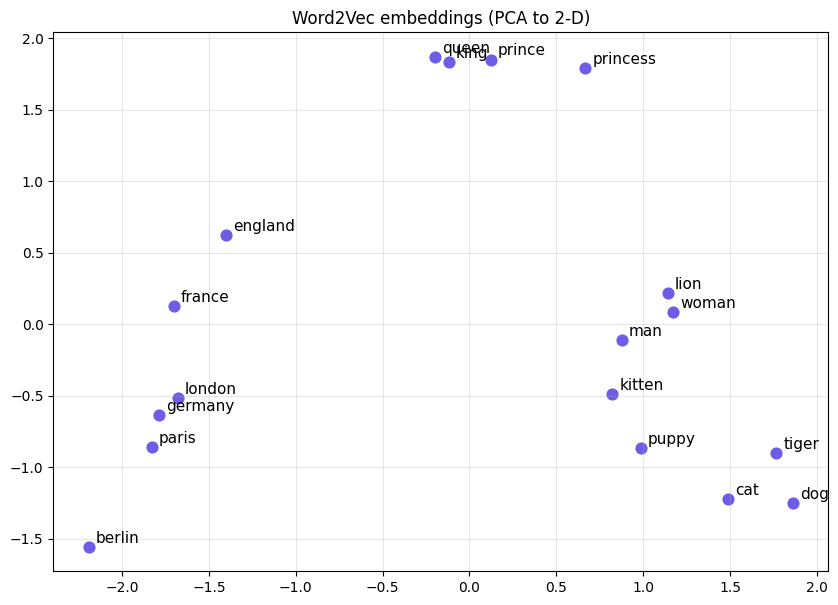

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

words = ["king", "queen", "man", "woman", "prince", "princess",
         "paris", "london", "france", "england", "germany", "berlin",
         "cat", "dog", "kitten", "puppy", "lion", "tiger"]
words = [w for w in words if w in model.wv]

vectors = np.array([model.wv[w] for w in words])
coords = PCA(n_components=2).fit_transform(vectors)

plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], c="#6C5CE7", s=60)
for w, (x, y) in zip(words, coords):
    plt.annotate(w, (x, y), fontsize=11, xytext=(5, 3), textcoords="offset points")
plt.title("Word2Vec embeddings (PCA to 2-D)")
plt.grid(alpha=0.3)
plt.show()

## 7 · Pretrained GloVe

**GloVe** (Global Vectors) is trained on global word co-occurrence statistics rather than local prediction windows. Training your own on a huge corpus is expensive, so we load **pretrained** vectors (Wikipedia + Gigaword, 50-D).

In [7]:
glove = api.load("glove-wiki-gigaword-50")   # ~66 MB download
print(f"GloVe vocabulary: {len(glove):,} words, dimension {glove['king'].shape[0]}")

# Same analogy, now with GloVe
print("\nGloVe:  king - man + woman  =")
for w, score in glove.most_similar(positive=["king", "woman"], negative=["man"], topn=3):
    print(f"   {w:12s} {score:.3f}")

[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe vocabulary: 400,000 words, dimension 50

GloVe:  king - man + woman  =
   queen        0.852
   throne       0.766
   prince       0.759


### Word2Vec vs. GloVe — a quick comparison

| | Word2Vec | GloVe |
|---|---|---|
| Approach | **Predictive** (local windows) | **Count-based** (global co-occurrence) |
| Data seen | Streams sentence by sentence | One big co-occurrence matrix |
| Strength | Handles huge corpora incrementally | Captures global statistics directly |

Both produce dense vectors where similar words sit close together — the shared insight that made them so influential.

In [8]:
# Compare how each ranks similarity for the same word
w = "computer"
print(f"Word2Vec neighbours of {w!r}:", [x for x, _ in model.wv.most_similar(w, topn=5)])
print(f"GloVe    neighbours of {w!r}:", [x for x, _ in glove.most_similar(w, topn=5)])

Word2Vec neighbours of 'computer': ['computers', 'bootstrap', 'hardware', 'asic', 'networked']
GloVe    neighbours of 'computer': ['computers', 'software', 'technology', 'electronic', 'internet']


## 8 · Your turn 🧪

1. **CBOW vs Skip-gram:** retrain with `sg=0`. Do the neighbours change?
2. **Dimensions:** try `vector_size=50` and `vector_size=300`. More isn't always better — check the analogies.
3. **Find a failure:** analogies aren't magic. Find an analogy that returns a *wrong* answer and think about why.
4. **Similarity score:** use `model.wv.similarity("cat", "dog")` vs `model.wv.similarity("cat", "france")` to quantify relatedness.
5. **Stretch:** load `glove-wiki-gigaword-300` and see whether the larger vectors resolve any analogies the 50-D ones got wrong.

In [9]:
# Scratch space for your experiments
